# Task - 1: Customer Preference Analysis

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import scipy.stats as st
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None) 
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', '{:.3f}'.format) 

sns.set_style("whitegrid")

In [15]:
base_path = Path.cwd().parents[1]  
file_path = base_path / "Notebooks" / "processed_data" / "Dataset_filtered.csv"
df = pd.read_csv(file_path)

In [16]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.800,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014,14.554,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.500,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.400,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056,14.585,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.900,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.058,14.584,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.800,Dark Green,Excellent,229


In [17]:
# Explode multi-cuisine entries so each row = one cuisine
df_exp = (
    df.assign(Cuisine=df["Cuisines"].str.split(", "))
        .explode("Cuisine")
)
df_exp["Cuisine"] = df_exp["Cuisine"].str.strip()
df_exp

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Cuisine
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.800,Dark Green,Excellent,314,French
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.800,Dark Green,Excellent,314,Japanese
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.028,14.565,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.800,Dark Green,Excellent,314,Desserts
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014,14.554,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.500,Dark Green,Excellent,591,Japanese
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.057,14.581,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.400,Green,Very Good,270,Seafood
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9538,5908749,Ceviz A��ac۱,208,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Ko��uyolu,"Ko��uyolu, ��stanbul",29.041,41.010,"World Cuisine, Patisserie, Cafe",105,Turkish Lira(TL),No,No,No,No,3,4.200,Green,Very Good,1034,Cafe
9539,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.035,41.056,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.700,Yellow,Good,661,Italian
9539,5915807,Huqqa,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.035,41.056,"Italian, World Cuisine",170,Turkish Lira(TL),No,No,No,No,4,3.700,Yellow,Good,661,World Cuisine
9540,5916112,A���k Kahve,208,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Kuru�_e��me,"Kuru�_e��me, ��stanbul",29.036,41.058,Restaurant Cafe,120,Turkish Lira(TL),No,No,No,No,4,4.000,Green,Very Good,901,Restaurant Cafe


### Type of Cuisine vs Restaurant Rating

In [18]:
valid = df_exp[df_exp["Aggregate rating"] > 0]
stats_1 = (
    valid.groupby("Cuisine")["Aggregate rating"]
            .agg(Avg_Rating="mean", Count="count")
            .reset_index()
)
stats_1

,Cuisine,Avg_Rating,Count
0,Afghani,3.450,8
1,African,4.029,7
2,American,3.758,380
3,Andhra,3.870,10
4,Arabian,3.792,25
...,...,...,...
138,Turkish Pizza,4.325,8
139,Vegetarian,4.074,23
140,Vietnamese,3.924,21
141,Western,4.140,10


In [19]:
# taking only those cuisines which are served at at least 20 restaurants
stats_1 = stats_1[stats_1["Count"] >= 20].sort_values("Avg_Rating", ascending=False).reset_index(drop=True)
stats_1["Avg_Rating"] = stats_1["Avg_Rating"].round(2)
stats_1.head(10)

,Cuisine,Avg_Rating,Count
0,Brazilian,4.340,23
1,International,4.250,21
2,Indian,4.160,66
3,Bar Food,4.150,37
4,Southern,4.130,24
5,Vegetarian,4.070,23
6,Sandwich,4.070,53
7,Grill,4.060,21
8,BBQ,4.030,32
9,Mediterranean,4.020,110


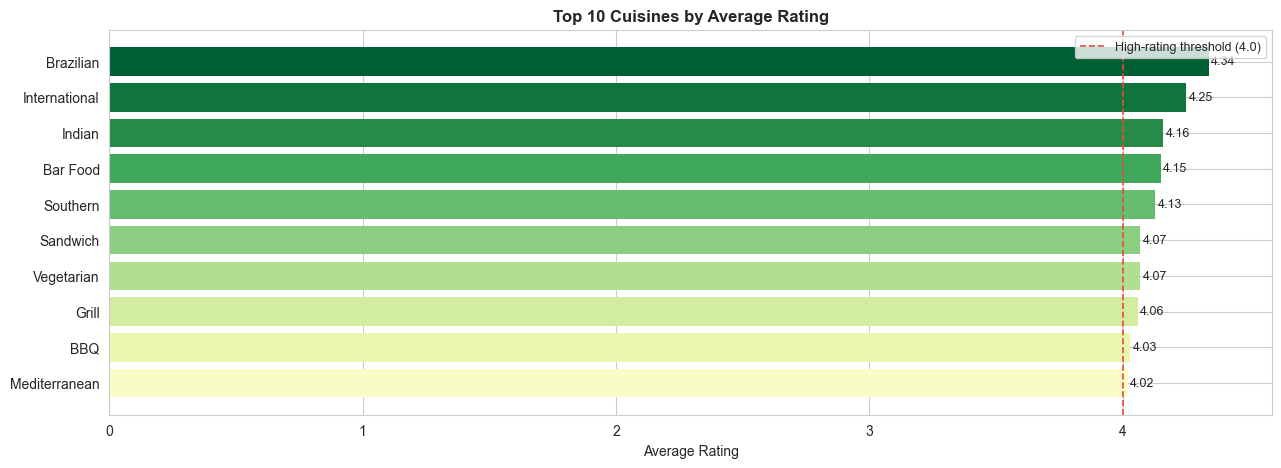

In [20]:
fig, ax = plt.subplots(figsize=(15,5))
top_r = stats_1.head(10).sort_values("Avg_Rating")
colors_r = sns.color_palette("YlGn", len(top_r))
bars = ax.barh(top_r["Cuisine"], top_r["Avg_Rating"], color=colors_r, edgecolor="none")
ax.axvline(x=4.0, color="#e74c3c", linestyle="--", linewidth=1.2,
            label=f"High-rating threshold ({4.0})")
for bar, val in zip(bars, top_r["Avg_Rating"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", ha="left", fontsize=9)
ax.set_xlabel("Average Rating")
ax.set_title(f"Top 10 Cuisines by Average Rating", fontweight="bold")
ax.set_xlim(right=top_r["Avg_Rating"].max() + 0.25)
ax.legend(loc='upper right', fontsize=9)
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "Top 10 Cuisines by Average Rating.png"
plt.savefig(file_path, dpi=150, bbox_inches='tight');

**Observation:**
- Brazilian cuisine leads
Brazilian restaurants average a 4.34 rating — the highest of any cuisine with sufficient data (20+ restaurants), edging out International (4.25) and Indian (4.16).

### Cuisisnes vs Votes

In [21]:
stats_2 = (
        df_exp.groupby("Cuisine")["Votes"]
              .agg(Total_Votes="sum", Count="count")
              .reset_index()
    )
stats_2 = stats_2[stats_2["Count"] >= 20].sort_values("Total_Votes", ascending=False).reset_index(drop=True)
stats_2.head(10)

,Cuisine,Total_Votes,Count
0,North Indian,595981,3960
1,Chinese,364351,2735
2,Italian,329265,764
3,Continental,288255,736
4,Fast Food,184058,1986
5,American,183117,390
6,Cafe,177568,703
7,Mughlai,151946,995
8,Desserts,105889,653
9,Asian,104303,233


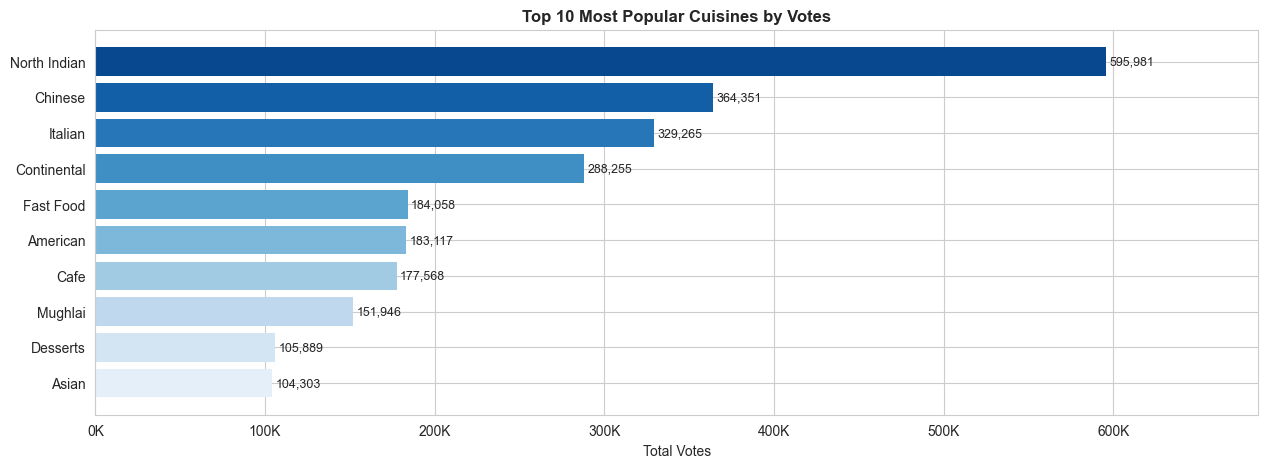

In [22]:
fig, ax = plt.subplots(figsize=(15,5))
top_v = stats_2.head(10).sort_values("Total_Votes")
colors_v = sns.color_palette("Blues_r", len(top_v))[::-1]
bars2 = ax.barh(top_v["Cuisine"], top_v["Total_Votes"], color=colors_v, edgecolor="none")
for bar, val in zip(bars2, top_v["Total_Votes"]):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height() / 2,
                f"{val:,.0f}", va="center", ha="left", fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))
ax.set_xlabel("Total Votes")
ax.set_title(f"Top 10 Most Popular Cuisines by Votes", fontweight="bold")
ax.set_xlim(right=top_v["Total_Votes"].max() * 1.15)
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "Top 10 Most Popular Cuisines by Votes.png"
plt.savefig(file_path, dpi=150, bbox_inches='tight');

**Observation:**
- North Indian dominates votes
North Indian cuisine has amassed ~596K votes across 3,960 restaurants — nearly double Chinese (364K votes), making it overwhelmingly the most customer-engaged cuisine.

### Trend analysis between cusine and rating

In [23]:
threshold = float(input("Enter threshold value for rating: "))
stats_3 = stats_1[stats_1["Avg_Rating"] >= threshold].reset_index(drop=True)
stats_3.head(20)

,Cuisine,Avg_Rating,Count
0,Brazilian,4.340,23
1,International,4.250,21
2,Indian,4.160,66
3,Bar Food,4.150,37
4,Southern,4.130,24
5,Vegetarian,4.070,23
6,Sandwich,4.070,53
7,Grill,4.060,21
8,BBQ,4.030,32
9,Mediterranean,4.020,110


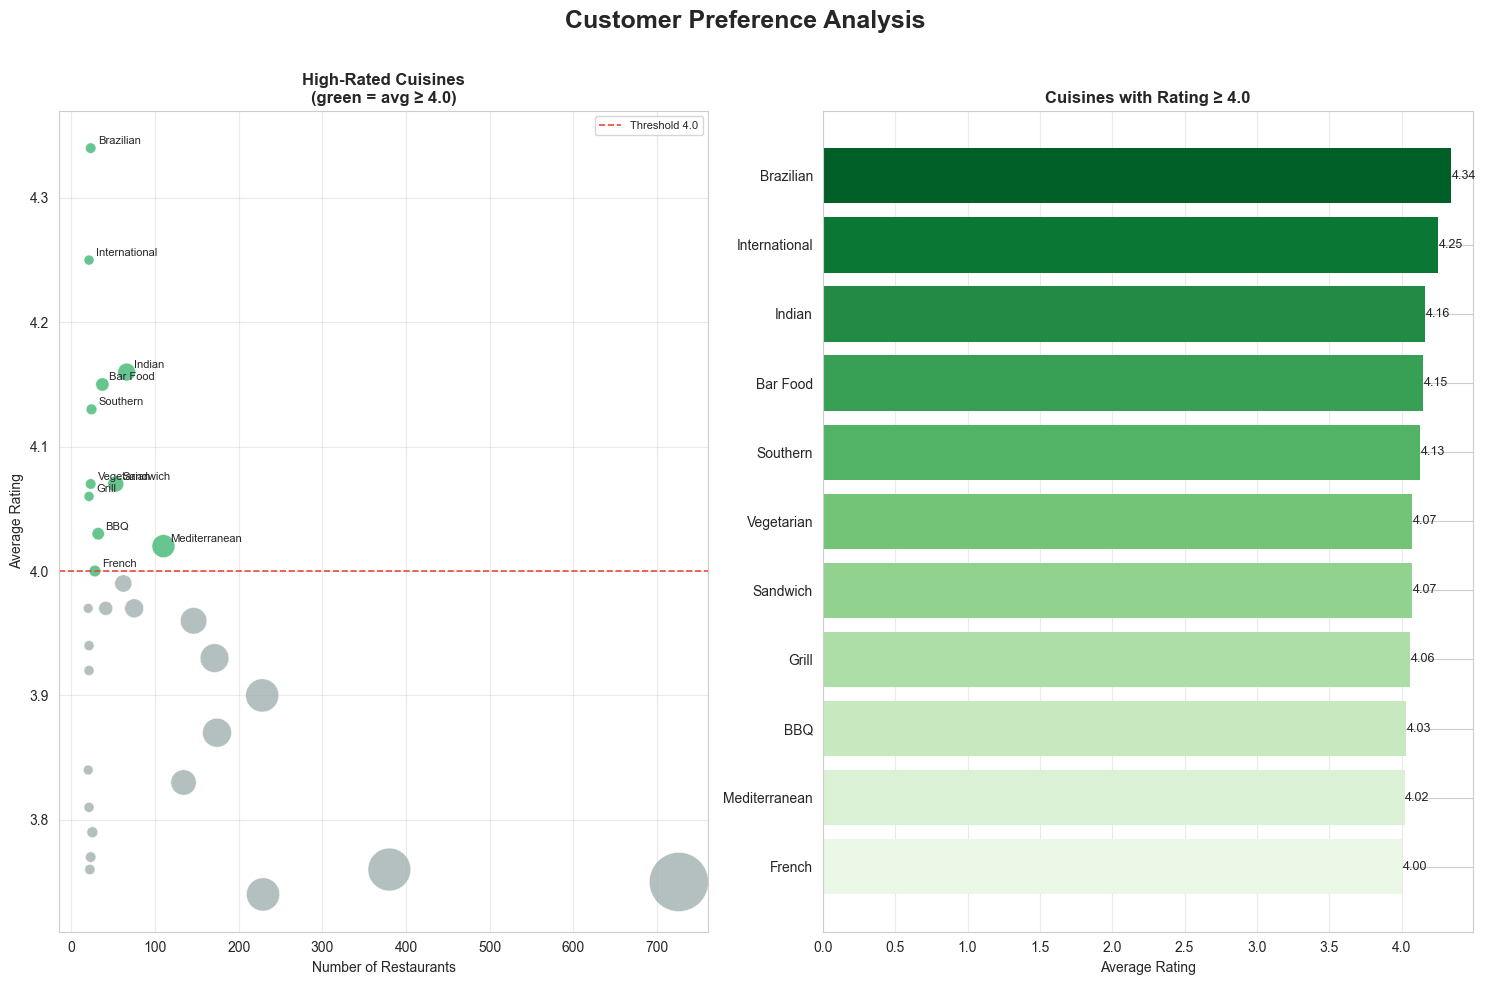

In [24]:
fig = plt.figure(figsize=(15,10))
fig.suptitle("Customer Preference Analysis", fontsize=18, fontweight="bold", y=0.98)
ax1 = fig.add_subplot(1, 2, 1)
scatter_df = stats_1.head(30)
high_mask = scatter_df["Avg_Rating"] >= threshold
colors_s = ["#27ae60" if m else "#95a5a6" for m in high_mask]
sc = ax1.scatter(scatter_df["Count"], scatter_df["Avg_Rating"],
                    s=scatter_df["Count"] * 2.5, c=colors_s, alpha=0.7, edgecolors="white", linewidths=0.5)
ax1.axhline(y=threshold, color="#e74c3c", linestyle="--", linewidth=1.2,
            label=f"Threshold {threshold}")
for _, row in scatter_df[high_mask].iterrows():
    ax1.annotate(row["Cuisine"], (row["Count"], row["Avg_Rating"]),
                    textcoords="offset points", xytext=(5, 3), fontsize=8)
ax1.set_xlabel("Number of Restaurants")
ax1.set_ylabel("Average Rating")
ax1.set_title("High-Rated Cuisines\n(green = avg ≥ 4.0)", fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.4)

ax2 = fig.add_subplot(1, 2, 2)
hd = stats_3.sort_values("Avg_Rating", ascending=True)
grad = sns.color_palette("Greens", len(hd))
ax2.barh(hd["Cuisine"], hd["Avg_Rating"], color=grad, edgecolor="none")
for i, (_, row) in enumerate(hd.iterrows()):
    ax2.text(row["Avg_Rating"] + 0.005, i, f"{row['Avg_Rating']:.2f}",
                va="center", fontsize=9)
ax2.set_xlabel("Average Rating")
ax2.set_xlim(right=hd["Avg_Rating"].max() + 0.15)
ax2.set_title(f"Cuisines with Rating ≥ {threshold}", fontweight="bold")
ax2.grid(axis="x", alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.97])
base_path = Path.cwd().parents[1]
file_path = base_path / "Notebooks" / "reports" / "cuisine_analysis_charts.png"
plt.savefig(file_path, dpi=150, bbox_inches="tight")
plt.show()

**Observation:**
- High-rated cuisines are niche
- 11 cuisines maintain a ≥4.0 average rating. Most have fewer than 70 restaurants — suggesting boutique cuisines like Brazilian, Bar Food, and Southern punch above their weight on quality.

### Summary:
> ***Cuisine vs. Rating relationship***
- Out of 145 unique cuisines, 11 maintain an average rating of 4.0 or above. 
- The top performers are 
  * Brazilian (4.34)
  * International (4.25) and 
  * Indian (4.16). Interestingly
- higher-rated cuisines tend to be more specialized (Bar Food, Southern BBQ, Grill) rather than mass-market offerings.

> ***Most popular cuisines by votes***
- North Indian is the runaway leader with ~596K total votes across 3,960 restaurants — nearly twice the second-place Chinese (364K). 
- The top 5 by volume are 
  * North Indian
  * Chinese, Italian
  * Continental and 
  * Fast Food
- These are all high-frequency, widely available cuisines.

> ***Cuisines that tend to receive higher ratings***
- There's a clear quality-vs-quantity tradeoff in the data. 
- The highest-rated cuisines are niche and have fewer locations (Brazilian has only 23 restaurants), while the most-voted cuisines (North Indian, Chinese, Fast Food) cluster in the 3.5–3.8 rating range. 
- Mediterranean is the standout exception — it achieves both a ≥4.0 rating and 80K+ votes across 110+ restaurants, making it the best of both worlds.